# Fluxa Voice Transaction Training Pipeline — Fixed v2

Notebook ini dibuat untuk training dan evaluasi **transaction parser/classifier** Fluxa.

Batasan penting:

- Dataset 5000 JSON/JSONL dipakai untuk classifier transaksi, bukan untuk fine-tuning Whisper.
- Whisper small tetap dipakai sebagai pretrained speech-to-text di backend.
- Amount/nominal memakai rule-based parser agar stabil dan mudah dijelaskan di skripsi.
- Output model wajib menjadi draft transaksi, bukan langsung disimpan ke database.
- Versi ini sudah mendukung dataset nested `raw_text + expected` dan flat `text + type`.


In [1]:
import sys
import numpy
import pandas
import sklearn
import fasttext

print("Python :", sys.version)
print("NumPy  :", numpy.__version__)
print("Pandas :", pandas.__version__)
print("SKLearn:", sklearn.__version__)
print("FastText OK")

Python : 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
NumPy  : 1.26.4
Pandas : 3.0.3
SKLearn: 1.9.0
FastText OK


## Update v2 — Dataset Nested Schema Fix

Notebook ini sudah diperbaiki agar bisa membaca dataset final Fluxa yang memakai struktur:

```json
{
  "raw_text": "...",
  "expected": {
    "type": "...",
    "amount": 5000,
    "category": "..."
  }
}
```

Notebook akan otomatis mengubahnya menjadi format training flat:

```text
text, type, amount, category, wallet, description, currency
```

Dengan ini, error `Missing required columns: ['text', 'type']` tidak akan muncul lagi.


## 0. Runtime Recommendation

- CPU Xxsmall cukup untuk validation, amount parser, dan baseline TF-IDF.
- GPU Xsmall disarankan untuk fine-tuning IndoBERT/XLM-R.
- Jalankan baseline dulu sebelum memakai GPU.


In [2]:
# Optional install cell. Uncomment ketika environment belum siap.
# %pip install -r ../requirements.txt


## 1. Imports & Path Setup


In [3]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset_loader import load_dataset, validate_dataset, save_json
from src.text_normalizer import normalize_text
from src.amount_parser import parse_amount
from src.metrics_utils import classification_metrics, evaluate_end_to_end

PROJECT_ROOT


WindowsPath('C:/Users/user/Fluxa/fluxa_voice_ai_training_pipeline')

## 2. Configuration

Ubah `DATASET_PATH` setelah kamu memindahkan dataset final ke folder `data/`.


In [4]:
EXPERIMENT_NAME = "fluxa_voice_intent_training_v1"
RANDOM_STATE = 42

DATASET_PATH = PROJECT_ROOT / "data" / "fluxa_voice_intent_dataset_sunda_5000.jsonl"
SAMPLE_DATASET_PATH = PROJECT_ROOT / "data" / "sample_dataset.jsonl"

MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for directory in [MODEL_DIR, REPORT_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TEXT_COL = "text"
TYPE_COL = "type"
CATEGORY_COL = "category"
WALLET_COL = "wallet"
AMOUNT_COL = "amount"
DESCRIPTION_COL = "description"

print("Experiment:", EXPERIMENT_NAME)
print("Dataset path:", DATASET_PATH)


Experiment: fluxa_voice_intent_training_v1
Dataset path: C:\Users\user\Fluxa\fluxa_voice_ai_training_pipeline\data\fluxa_voice_intent_dataset_sunda_5000.jsonl


## 3. Load Dataset

Notebook ini sekarang mendukung 2 format dataset:

1. **Flat format** — sudah punya kolom `text`, `type`, `amount`, `category`, dll.
2. **Nested Fluxa format** — punya `raw_text` dan object `expected`.

Jika dataset masih nested, notebook akan otomatis membuat versi flat ke:

```text
data/fluxa_voice_intent_dataset_sunda_5000_fixed.jsonl
```


In [5]:
active_dataset_path = DATASET_PATH if DATASET_PATH.exists() else SAMPLE_DATASET_PATH
print("Using dataset:", active_dataset_path)

df_raw = load_dataset(active_dataset_path)
print("Raw shape:", df_raw.shape)
print("Raw columns:", df_raw.columns.tolist())
df_raw.head()


Using dataset: C:\Users\user\Fluxa\fluxa_voice_ai_training_pipeline\data\fluxa_voice_intent_dataset_sunda_5000.jsonl
Raw shape: (5000, 9)
Raw columns: ['language_style', 'raw_text', 'normalized_text', 'expected', 'difficulty', 'case_type', 'id', 'group', 'split']


,language_style,raw_text,normalized_text,expected,difficulty,case_type,id,group,split
0,su,poé ieu meuli kuota internét sakitar tujuh pul...,poé ieu meuli kuota internét sakitar 75000,"{'amount': 75000, 'type': 'expense', 'category...",easy,expense_basic,VX-SU-000001,expense_basic,train
1,su,abdi mayar saratus rébu keur dokter,abdi mayar 100000 keur dokter,"{'amount': 100000, 'type': 'expense', 'categor...",easy,expense_basic,VX-SU-000002,expense_basic,train
2,su,meuli dua belas rebu keur roti,meuli 12000 keur roti,"{'amount': 12000, 'type': 'expense', 'category...",easy,expense_basic,VX-SU-000003,expense_basic,train
3,su,urang meuli bensin sakitar 30rb,urang meuli bensin sakitar 30000,"{'amount': 30000, 'type': 'expense', 'category...",easy,expense_basic,VX-SU-000004,expense_basic,train
4,su,minggu ieu bioskop 30rb,minggu ieu bioskop 30000,"{'amount': 30000, 'type': 'expense', 'category...",easy,expense_basic,VX-SU-000005,expense_basic,train


## 3.1 Dataset Schema Normalization

Cell ini memperbaiki error:

```text
ValueError: Missing required columns: ['text', 'type']
```

Penyebabnya: dataset Fluxa final memakai format nested (`raw_text` + `expected`) sementara validator membutuhkan format flat (`text`, `type`, `amount`, `category`, ...).


In [6]:
def _safe_expected(value) -> dict:
    """Return expected dict from dict/string/empty value."""
    if isinstance(value, dict):
        return value
    if isinstance(value, str) and value.strip():
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else {}
        except json.JSONDecodeError:
            return {}
    return {}


def coerce_fluxa_dataset_schema(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Convert nested Fluxa JSONL schema into flat training schema.

    Supported input variants:
    - Flat: text, type, amount, category, wallet, description
    - Nested: raw_text, normalized_text, expected: {type, amount, category, wallet, note, currency}
    """
    df = raw_df.copy()

    # 1. Text column
    if "text" not in df.columns:
        if "raw_text" in df.columns:
            df["text"] = df["raw_text"]
        elif "normalized_text" in df.columns:
            df["text"] = df["normalized_text"]
        else:
            raise ValueError("Dataset must contain either `text`, `raw_text`, or `normalized_text`.")

    # 2. Flatten expected object if present
    if "expected" in df.columns:
        expected = df["expected"].map(_safe_expected)

        mapping = {
            "type": "type",
            "amount": "amount",
            "category": "category",
            "wallet": "wallet",
            "currency": "currency",
        }

        for out_col, expected_key in mapping.items():
            if out_col not in df.columns or df[out_col].isna().all():
                df[out_col] = expected.map(lambda item: item.get(expected_key))

        if "description" not in df.columns or df["description"].isna().all():
            df["description"] = expected.map(
                lambda item: item.get("description") or item.get("note")
            )

    # 3. Sensible fallbacks
    if "description" not in df.columns:
        df["description"] = None
    if "wallet" not in df.columns:
        df["wallet"] = None
    if "currency" not in df.columns:
        df["currency"] = "IDR"

    df["currency"] = df["currency"].fillna("IDR")

    if "amount" in df.columns:
        df["amount"] = pd.to_numeric(df["amount"], errors="coerce").astype("Int64")

    # 4. Keep useful columns first; preserve metadata columns after that
    preferred_columns = [
        "id",
        "text",
        "normalized_text",
        "type",
        "amount",
        "category",
        "wallet",
        "description",
        "currency",
        "language_style",
        "difficulty",
        "case_type",
        "group",
        "split",
    ]
    ordered = [col for col in preferred_columns if col in df.columns]
    rest = [col for col in df.columns if col not in ordered and col != "expected"]
    return df[ordered + rest]


df_prepared = coerce_fluxa_dataset_schema(df_raw)

FIXED_DATASET_PATH = PROJECT_ROOT / "data" / "fluxa_voice_intent_dataset_sunda_5000_fixed.jsonl"
if active_dataset_path == DATASET_PATH or len(df_prepared) >= 100:
    FIXED_DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_prepared.to_json(
        FIXED_DATASET_PATH,
        orient="records",
        lines=True,
        force_ascii=False,
    )
    print("Saved normalized dataset:", FIXED_DATASET_PATH)

print("Prepared shape:", df_prepared.shape)
print("Prepared columns:", df_prepared.columns.tolist())
df_prepared.head()


Saved normalized dataset: C:\Users\user\Fluxa\fluxa_voice_ai_training_pipeline\data\fluxa_voice_intent_dataset_sunda_5000_fixed.jsonl
Prepared shape: (5000, 15)
Prepared columns: ['id', 'text', 'normalized_text', 'type', 'amount', 'category', 'wallet', 'description', 'currency', 'language_style', 'difficulty', 'case_type', 'group', 'split', 'raw_text']


,id,text,normalized_text,type,amount,category,wallet,description,currency,language_style,difficulty,case_type,group,split,raw_text
0,VX-SU-000001,poé ieu meuli kuota internét sakitar tujuh pul...,poé ieu meuli kuota internét sakitar 75000,expense,75000,Tagihan & Utilitas,NaN,kuota internét,IDR,su,easy,expense_basic,expense_basic,train,poé ieu meuli kuota internét sakitar tujuh pul...
1,VX-SU-000002,abdi mayar saratus rébu keur dokter,abdi mayar 100000 keur dokter,expense,100000,Kesehatan,NaN,dokter,IDR,su,easy,expense_basic,expense_basic,train,abdi mayar saratus rébu keur dokter
2,VX-SU-000003,meuli dua belas rebu keur roti,meuli 12000 keur roti,expense,12000,Makan & Minum,NaN,roti,IDR,su,easy,expense_basic,expense_basic,train,meuli dua belas rebu keur roti
3,VX-SU-000004,urang meuli bensin sakitar 30rb,urang meuli bensin sakitar 30000,expense,30000,Transportasi,NaN,bensin,IDR,su,easy,expense_basic,expense_basic,train,urang meuli bensin sakitar 30rb
4,VX-SU-000005,minggu ieu bioskop 30rb,minggu ieu bioskop 30000,expense,30000,Hiburan,NaN,bioskop,IDR,su,easy,expense_basic,expense_basic,train,minggu ieu bioskop 30rb


## 4. Dataset Validation

Validasi memastikan data siap training dan menyimpan summary ke `reports/dataset_summary.json`.


In [7]:
df_valid, df_invalid, dataset_summary = validate_dataset(df_prepared)

save_json(dataset_summary, REPORT_DIR / "dataset_summary.json")
if not df_invalid.empty:
    df_invalid.to_csv(REPORT_DIR / "invalid_rows.csv", index=False)

print(json.dumps(dataset_summary, ensure_ascii=False, indent=2))
print("Invalid rows:", len(df_invalid))
df_valid.head()


{
  "total_rows": 5000,
  "valid_rows": 5000,
  "invalid_rows": 0,
  "duplicate_texts": 0,
  "type_distribution": {
    "expense": 3076,
    "income": 1724,
    "transfer": 200
  },
  "category_distribution": {
    "Transportasi": 1015,
    "Freelance": 900,
    "Gaji": 824,
    "Tagihan & Utilitas": 438,
    "Belanja": 419,
    "Hiburan": 413,
    "Makan & Minum": 403,
    "Kesehatan": 388,
    "Transfer": 200
  },
  "wallet_null_count": 4300
}
Invalid rows: 0


,id,text,normalized_text,type,amount,category,wallet,description,currency,language_style,difficulty,case_type,group,split,raw_text
0,VX-SU-000001,poé ieu meuli kuota internét sakitar tujuh pul...,poé ieu meuli kuota internét sakitar 75000,expense,75000,Tagihan & Utilitas,NaN,kuota internét,IDR,su,easy,expense_basic,expense_basic,train,poé ieu meuli kuota internét sakitar tujuh pul...
1,VX-SU-000002,abdi mayar saratus rébu keur dokter,abdi mayar 100000 keur dokter,expense,100000,Kesehatan,NaN,dokter,IDR,su,easy,expense_basic,expense_basic,train,abdi mayar saratus rébu keur dokter
2,VX-SU-000003,meuli dua belas rebu keur roti,meuli 12000 keur roti,expense,12000,Makan & Minum,NaN,roti,IDR,su,easy,expense_basic,expense_basic,train,meuli dua belas rebu keur roti
3,VX-SU-000004,urang meuli bensin sakitar 30rb,urang meuli bensin sakitar 30000,expense,30000,Transportasi,NaN,bensin,IDR,su,easy,expense_basic,expense_basic,train,urang meuli bensin sakitar 30rb
4,VX-SU-000005,minggu ieu bioskop 30rb,minggu ieu bioskop 30000,expense,30000,Hiburan,NaN,bioskop,IDR,su,easy,expense_basic,expense_basic,train,minggu ieu bioskop 30rb


## 5. Cleaning & Normalization

Normalizer dibuat konservatif agar variasi Sunda/Indonesia tetap terbaca oleh model.


In [8]:
df = df_valid.copy()
df["normalized_text"] = df[TEXT_COL].map(normalize_text)

df[[TEXT_COL, "normalized_text", TYPE_COL, CATEGORY_COL, AMOUNT_COL]].head(10)


,text,normalized_text,type,category,amount
0,poé ieu meuli kuota internét sakitar tujuh pul...,poé ieu beli kuota internét sakitar tujuh pulu...,expense,Tagihan & Utilitas,75000
1,abdi mayar saratus rébu keur dokter,abdi bayar saratus rébu keur dokter,expense,Kesehatan,100000
2,meuli dua belas rebu keur roti,beli dua belas ribu keur roti,expense,Makan & Minum,12000
3,urang meuli bensin sakitar 30rb,urang beli bensin sakitar 30rb,expense,Transportasi,30000
4,minggu ieu bioskop 30rb,minggu ieu bioskop 30rb,expense,Hiburan,30000
5,abdi cilok 5rb,abdi cilok 5rb,expense,Makan & Minum,5000
6,mayar kuota internét sakitar 100rb,bayar kuota internét sakitar 100rb,expense,Tagihan & Utilitas,100000
7,kamari meuli game sakitar 100rb,kamari beli game sakitar 100rb,expense,Hiburan,100000
8,poé ieu top up game 50rb,poé ieu top up game 50rb,expense,Hiburan,50000
9,isuk tadi balanja balanja bulanan Rp400.000,isuk tadi balanja balanja bulanan rp400 000,expense,Belanja,400000


## 6. Exploratory Data Analysis


In [9]:
print("Rows:", len(df))
print("Duplicate normalized texts:", df["normalized_text"].duplicated().sum())
print("Type distribution:")
print(df[TYPE_COL].value_counts())

if CATEGORY_COL in df.columns:
    print("\nTop categories:")
    print(df[CATEGORY_COL].value_counts().head(20))

if WALLET_COL in df.columns:
    print("\nWallet null ratio:", float(df[WALLET_COL].isna().mean()))


Rows: 5000
Duplicate normalized texts: 0
Type distribution:
type
expense     3076
income      1724
transfer     200
Name: count, dtype: int64

Top categories:
category
Transportasi          1015
Freelance              900
Gaji                   824
Tagihan & Utilitas     438
Belanja                419
Hiburan                413
Makan & Minum          403
Kesehatan              388
Transfer               200
Name: count, dtype: int64

Wallet null ratio: 0.86


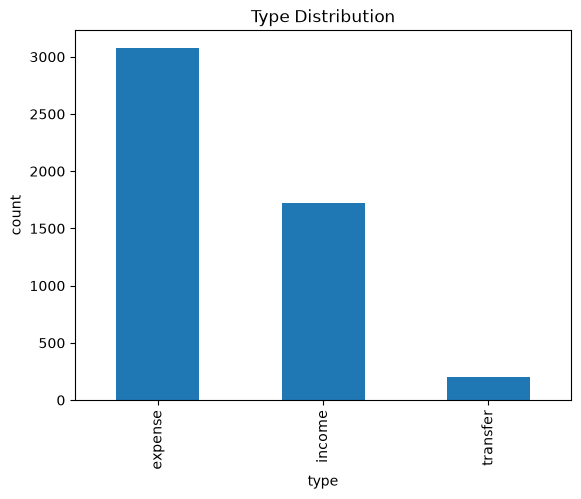

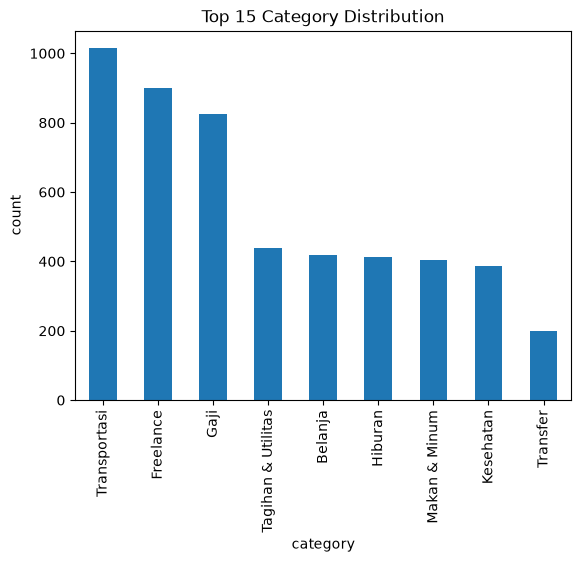

In [10]:
# Simple plots. No custom colors to keep this notebook portable.
df[TYPE_COL].value_counts().plot(kind="bar", title="Type Distribution")
plt.xlabel("type")
plt.ylabel("count")
plt.show()

if CATEGORY_COL in df.columns:
    df[CATEGORY_COL].value_counts().head(15).plot(kind="bar", title="Top 15 Category Distribution")
    plt.xlabel("category")
    plt.ylabel("count")
    plt.show()


## 7. Amount Parser Evaluation

Nominal uang diproses rule-based, bukan classifier. Ini lebih stabil untuk ekspresi seperti `lima rebu`, `35rb`, dan `dua juta`.


In [11]:
df["pred_amount"] = df["normalized_text"].map(parse_amount)

if AMOUNT_COL in df.columns:
    amount_eval = df.dropna(subset=[AMOUNT_COL]).copy()
    amount_eval["amount_correct"] = amount_eval[AMOUNT_COL].astype("Int64") == amount_eval["pred_amount"].astype("Int64")
    amount_metrics = {
        "samples": int(len(amount_eval)),
        "exact_match_accuracy": float(amount_eval["amount_correct"].mean()) if len(amount_eval) else None,
    }
    save_json(amount_metrics, REPORT_DIR / "amount_parser_metrics.json")
    amount_eval.loc[~amount_eval["amount_correct"], [TEXT_COL, "normalized_text", AMOUNT_COL, "pred_amount"]].to_csv(
        REPORT_DIR / "amount_parser_errors.csv", index=False
    )
    print(json.dumps(amount_metrics, indent=2))
    display(amount_eval[[TEXT_COL, AMOUNT_COL, "pred_amount", "amount_correct"]].head(20))
else:
    print("No amount column found; skipping amount evaluation.")


{
  "samples": 5000,
  "exact_match_accuracy": 1.0
}


,text,amount,pred_amount,amount_correct
0,poé ieu meuli kuota internét sakitar tujuh pul...,75000,75000,True
1,abdi mayar saratus rébu keur dokter,100000,100000,True
2,meuli dua belas rebu keur roti,12000,12000,True
3,urang meuli bensin sakitar 30rb,30000,30000,True
4,minggu ieu bioskop 30rb,30000,30000,True
5,abdi cilok 5rb,5000,5000,True
6,mayar kuota internét sakitar 100rb,100000,100000,True
7,kamari meuli game sakitar 100rb,100000,100000,True
8,poé ieu top up game 50rb,50000,50000,True
9,isuk tadi balanja balanja bulanan Rp400.000,400000,400000,True


## 8. Train / Validation / Test Split

Split default: 80% train, 10% validation, 10% test. Untuk dataset kecil/sample, stratify bisa gagal; notebook akan fallback otomatis.


In [12]:
required_for_training = ["normalized_text", TYPE_COL, CATEGORY_COL]
missing = [col for col in required_for_training if col not in df.columns]
if missing:
    raise ValueError(f"Missing required training columns: {missing}")

# Prefer dataset-provided split when available and complete.
if "split" in df.columns and {"train", "validation", "test"}.issubset(set(df["split"].dropna().unique())):
    train_df = df[df["split"] == "train"].copy()
    val_df = df[df["split"] == "validation"].copy()
    test_df = df[df["split"] == "test"].copy()
    print("Using predefined split column.")
else:
    print("Using generated 80/10/10 split.")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=df[TYPE_COL] if df[TYPE_COL].value_counts().min() >= 2 else None,
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp_df[TYPE_COL] if temp_df[TYPE_COL].value_counts().min() >= 2 else None,
    )

print("train:", train_df.shape)
print("validation:", val_df.shape)
print("test:", test_df.shape)


Using predefined split column.
train: (4000, 16)
validation: (500, 16)
test: (500, 16)


## 9. Label Mapping Export


In [13]:
type_labels = sorted(df[TYPE_COL].dropna().unique().tolist())
category_labels = sorted(df[CATEGORY_COL].dropna().unique().tolist())
wallet_labels = sorted(df[WALLET_COL].dropna().unique().tolist()) if WALLET_COL in df.columns else []

label_maps = {
    "type2id": {label: i for i, label in enumerate(type_labels)},
    "id2type": {i: label for i, label in enumerate(type_labels)},
    "category2id": {label: i for i, label in enumerate(category_labels)},
    "id2category": {i: label for i, label in enumerate(category_labels)},
    "wallet2id": {label: i for i, label in enumerate(wallet_labels)},
    "id2wallet": {i: label for i, label in enumerate(wallet_labels)},
}

save_json(label_maps, MODEL_DIR / "label_mappings.json")
print(json.dumps(label_maps, ensure_ascii=False, indent=2))


{
  "type2id": {
    "expense": 0,
    "income": 1,
    "transfer": 2
  },
  "id2type": {
    "0": "expense",
    "1": "income",
    "2": "transfer"
  },
  "category2id": {
    "Belanja": 0,
    "Freelance": 1,
    "Gaji": 2,
    "Hiburan": 3,
    "Kesehatan": 4,
    "Makan & Minum": 5,
    "Tagihan & Utilitas": 6,
    "Transfer": 7,
    "Transportasi": 8
  },
  "id2category": {
    "0": "Belanja",
    "1": "Freelance",
    "2": "Gaji",
    "3": "Hiburan",
    "4": "Kesehatan",
    "5": "Makan & Minum",
    "6": "Tagihan & Utilitas",
    "7": "Transfer",
    "8": "Transportasi"
  },
  "wallet2id": {
    "BCA": 0,
    "BRI": 1,
    "Cash": 2,
    "Dana": 3,
    "GoPay": 4,
    "Mandiri": 5,
    "OVO": 6,
    "ShopeePay": 7
  },
  "id2wallet": {
    "0": "BCA",
    "1": "BRI",
    "2": "Cash",
    "3": "Dana",
    "4": "GoPay",
    "5": "Mandiri",
    "6": "OVO",
    "7": "ShopeePay"
  }
}


## 10. Baseline Classifier: FastText

Model baseline menggunakan FastText sebagai pembanding utama pada eksperimen klasifikasi jenis transaksi dan kategori transaksi.


In [22]:
print("Train rows:", len(train_df))

print(
    "Type train file size:",
    type_train_file.stat().st_size / 1024 / 1024,
    "MB"
)

print(
    "Category train file size:",
    category_train_file.stat().st_size / 1024 / 1024,
    "MB"
)

Train rows: 4000
Type train file size: 0.22227954864501953 MB
Category train file size: 0.23302364349365234 MB


In [26]:

import fasttext

def export_fasttext_dataset(df, text_col, label_col, output_path):
    lines = []

    for _, row in df.iterrows():
        text = str(row.get(text_col, "") or "").strip()
        label = str(row.get(label_col, "") or "").strip()

        if not text or not label:
            continue

        lines.append(f"__label__{label} {text}")

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

    return output_path

type_train_file = MODEL_DIR / "type_train_fasttext.txt"
category_train_file = MODEL_DIR / "category_train_fasttext.txt"

export_fasttext_dataset(
    train_df,
    text_col="normalized_text",
    label_col=TYPE_COL,
    output_path=type_train_file,
)

export_fasttext_dataset(
    train_df,
    text_col="normalized_text",
    label_col=CATEGORY_COL,
    output_path=category_train_file,
)

type_model = fasttext.train_supervised(
    input=str(type_train_file),
    epoch=25,
    lr=0.3,
    dim=50,
    wordNgrams=2,
    minn=2,
    maxn=4,
    bucket=50000,
    loss="softmax",
)

category_model = fasttext.train_supervised(
    input=str(category_train_file),
    epoch=25,
    lr=0.3,
    dim=50,
    wordNgrams=2,
    minn=2,
    maxn=4,
    bucket=50000,
    loss="softmax",
)

type_model.quantize(
    input=str(type_train_file),
    retrain=True,
)

category_model.quantize(
    input=str(category_train_file),
    retrain=True,
)

type_model.save_model(
    str(MODEL_DIR / "baseline_type_classifier.ftz")
)

category_model.save_model(
    str(MODEL_DIR / "baseline_category_classifier.ftz")
)
print("Baseline models saved:")
print("-", MODEL_DIR / "baseline_type_classifier.bin")
print("-", MODEL_DIR / "baseline_category_classifier.bin")


Baseline models saved:
- C:\Users\user\Fluxa\fluxa_voice_ai_training_pipeline\models\baseline_type_classifier.bin
- C:\Users\user\Fluxa\fluxa_voice_ai_training_pipeline\models\baseline_category_classifier.bin


## 11. Baseline Evaluation


In [15]:

def predict_fasttext_label(model, text):
    text = str(text or "").strip()

    if not text:
        return None

    labels, scores = model.predict(text)

    if not labels:
        return None

    return labels[0].replace("__label__", "")

test_eval = test_df.copy()

test_eval["pred_type"] = test_eval["normalized_text"].apply(
    lambda x: predict_fasttext_label(type_model, x)
)

test_eval["pred_category"] = test_eval["normalized_text"].apply(
    lambda x: predict_fasttext_label(category_model, x)
)

test_eval["pred_amount"] = test_eval["normalized_text"].map(parse_amount)

type_metrics = classification_metrics(
    test_eval[TYPE_COL],
    test_eval["pred_type"],
)

category_metrics = classification_metrics(
    test_eval[CATEGORY_COL],
    test_eval["pred_category"],
)

save_json(type_metrics, REPORT_DIR / "baseline_type_metrics.json")
save_json(category_metrics, REPORT_DIR / "baseline_category_metrics.json")

test_eval.to_csv(REPORT_DIR / "baseline_test_predictions.csv", index=False)

print("Type metrics:")
print(json.dumps({k: v for k, v in type_metrics.items() if k != "classification_report"}, indent=2))

print("\\nCategory metrics:")
print(json.dumps({k: v for k, v in category_metrics.items() if k != "classification_report"}, indent=2))


Type metrics:
{
  "accuracy": 1.0,
  "macro_f1": 1.0,
  "weighted_f1": 1.0
}
\nCategory metrics:
{
  "accuracy": 0.84,
  "macro_f1": 0.6975871914839051,
  "weighted_f1": 0.7792654618401098
}


## 12. End-to-End Evaluation


In [16]:
if AMOUNT_COL in test_eval.columns:
    e2e_metrics = evaluate_end_to_end(test_eval)
    save_json(e2e_metrics, REPORT_DIR / "end_to_end_metrics.json")
    print(json.dumps(e2e_metrics, indent=2))
else:
    print("No amount column found; E2E amount evaluation skipped.")


{
  "samples": 500,
  "type_accuracy": 1.0,
  "category_accuracy": 0.84,
  "amount_accuracy": 1.0,
  "all_fields_accuracy": 0.84
}


## 13. Transformer Fine-Tuning Template: IndoBERT/XLM-R

Jalankan section ini hanya saat memakai GPU. Untuk eksperimen awal, baseline sudah cukup.

Rekomendasi:

- IndoBERT: `indobenchmark/indobert-base-p1`
- XLM-R: `xlm-roberta-base`


In [17]:
RUN_TRANSFORMER_TRAINING = False
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 96
NUM_EPOCHS = 5

print("Transformer training enabled:", RUN_TRANSFORMER_TRAINING)


Transformer training enabled: False


In [18]:
if RUN_TRANSFORMER_TRAINING:
    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
    )

    target_col = TYPE_COL  # Change to CATEGORY_COL for category classifier.
    labels = sorted(df[target_col].dropna().unique().tolist())
    label2id = {label: idx for idx, label in enumerate(labels)}
    id2label = {idx: label for label, idx in label2id.items()}

    hf_train = Dataset.from_pandas(train_df[["normalized_text", target_col]].rename(columns={target_col: "label"}))
    hf_val = Dataset.from_pandas(val_df[["normalized_text", target_col]].rename(columns={target_col: "label"}))

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def preprocess(batch):
        tokenized = tokenizer(batch["normalized_text"], truncation=True, max_length=MAX_LENGTH)
        tokenized["labels"] = [label2id[x] for x in batch["label"]]
        return tokenized

    hf_train = hf_train.map(preprocess, batched=True)
    hf_val = hf_val.map(preprocess, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id,
    )

    training_args = TrainingArguments(
        output_dir=str(MODEL_DIR / "transformer_type_classifier"),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_steps=25,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    trainer.train()
    trainer.save_model(str(MODEL_DIR / "transformer_type_classifier"))
    tokenizer.save_pretrained(str(MODEL_DIR / "transformer_type_classifier"))
    save_json({"label2id": label2id, "id2label": id2label}, MODEL_DIR / "transformer_type_classifier" / "label_mapping.json")
else:
    print("Skipped transformer training.")


Skipped transformer training.


## 14. Local Inference Demo

Cell ini menunjukkan output yang nanti dikembalikan backend FastAPI ke Flutter.


In [19]:

import fasttext

type_model = fasttext.load_model(
    str(MODEL_DIR / "baseline_type_classifier.bin")
)

category_model = fasttext.load_model(
    str(MODEL_DIR / "baseline_category_classifier.bin")
)

def predict_label(model, text: str) -> str:
    labels, scores = model.predict(text)

    if not labels:
        return ""

    return labels[0].replace("__label__", "")

def predict_transaction_json(text: str) -> dict:
    normalized = normalize_text(text)

    pred_type = predict_label(type_model, normalized)
    pred_category = predict_label(category_model, normalized)
    pred_amount = parse_amount(normalized)

    return {
        "transcript": {
            "raw": text,
            "normalized": normalized,
            "language_hint": None,
            "confidence": None,
        },
        "transaction": {
            "type": pred_type,
            "amount": pred_amount,
            "category": pred_category,
            "wallet": None,
            "description": normalized,
            "currency": "IDR",
        },
        "classification": {
            "raw_type": pred_type,
            "resolved_type": pred_type,
            "category": pred_category,
        },
        "warnings": [],
    }

examples = [
    "mayar parkir motor lima rebu",
    "beli kopi 35rb dari bca",
    "nampi gajih dua juta",
]

for example in examples:
    print(json.dumps(predict_transaction_json(example), ensure_ascii=False, indent=2))


{
  "transcript": {
    "raw": "mayar parkir motor lima rebu",
    "normalized": "bayar parkir motor lima ribu",
    "language_hint": null,
    "confidence": null
  },
  "transaction": {
    "type": "expense",
    "amount": 5000,
    "category": "Transportasi",
    "wallet": null,
    "description": "bayar parkir motor lima ribu",
    "currency": "IDR"
  },
  "classification": {
    "raw_type": "expense",
    "resolved_type": "expense",
    "category": "Transportasi"
  },
  "warnings": []
}
{
  "transcript": {
    "raw": "beli kopi 35rb dari bca",
    "normalized": "beli kopi 35rb dari bca",
    "language_hint": null,
    "confidence": null
  },
  "transaction": {
    "type": "expense",
    "amount": 35000,
    "category": "Belanja",
    "wallet": null,
    "description": "beli kopi 35rb dari bca",
    "currency": "IDR"
  },
  "classification": {
    "raw_type": "expense",
    "resolved_type": "expense",
    "category": "Belanja"
  },
  "warnings": []
}
{
  "transcript": {
    "raw": "